In [1]:
# ==========================================
# 1. Environment Setup & Library Imports (Local Version)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Scikit-learn modules for preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# Configuration Settings
# ----------------------
# Display all columns (don't truncate view)
pd.set_option('display.max_columns', None)
# Display floats with 4 decimal places for readability
pd.set_option('display.float_format', lambda x: '%.4f' % x)
# Ignore annoying warnings
warnings.filterwarnings('ignore')

In [2]:
# ==========================================
# 2. Load Dataset & Initial Health Check
# ==========================================

file_path = '../data/raw/cic-collection.parquet'

try:
    # Read Parquet file (More efficient than CSV)
    df = pd.read_parquet(file_path)
        
    # Basic Statistics
    rows, cols = df.shape
    memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2) # Convert bytes to MB
    
    print(f"Dataset Overview:")
    print(f"   - Total Rows:    {rows:,}")
    print(f"   - Total Columns: {cols}")
    print(f"   - Memory Usage:  {memory_usage:.2f} MB")
    print("="*40)

    # Show first 3 rows to verify data structure
    print("\nSample Data (Head):")
    display(df.head(3))

except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset Overview:
   - Total Rows:    9,167,581
   - Total Columns: 59
   - Memory Usage:  3651.28 MB

Sample Data (Head):


,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,SYN Flag Count,URG Flag Count,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,ClassLabel
0,4,2,0,12.0000,0.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,3000000.0000,500000.0000,4.0000,0.0000,4.0000,4.0000,4.0000,4.0000,0.0000,4.0000,4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,40,0,500000.0000,0.0000,6.0000,6.0000,0.0000,0.0000,0,1,9.0000,6.0000,0.0000,2,12,0,0,329,-1,1,20,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Benign,Benign
1,1,2,0,12.0000,0.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,40,0,2000000.0000,0.0000,6.0000,6.0000,0.0000,0.0000,0,1,9.0000,6.0000,0.0000,2,12,0,0,329,-1,1,20,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Benign,Benign
2,3,2,0,12.0000,0.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3.0000,3.0000,3.0000,3.0000,0.0000,3.0000,3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,40,0,666666.6875,0.0000,6.0000,6.0000,0.0000,0.0000,0,1,9.0000,6.0000,0.0000,2,12,0,0,245,-1,1,20,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Benign,Benign


In [3]:
# ==========================================
# 3. Data Cleaning & Memory Optimization
# ==========================================

def optimize_memory(df):
    """
    Downcasts numeric columns to save memory.
    float64 -> float32, int64 -> int32/int16/int8.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print("Starting Memory Optimization...")
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory Optimization Completed!")
    print(f"   - Before: {start_mem:.2f} MB")
    print(f"   - After:  {end_mem:.2f} MB")
    print(f"   - Saved:  {100 * (start_mem - end_mem) / start_mem:.1f}%")
    return df

# A. Clean Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Column names standardized (lowercase, underscores).")

# B. Drop Blacklisted Columns (including classlabel duplicate)
drop_cols = [
    'flow_id', 'source_ip', 'src_ip', 'source_port', 
    'destination_ip', 'dst_ip', 'timestamp', 'date',
    'classlabel'  # FIXED: Drop duplicate label column
]
dropped_actual = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, errors='ignore', inplace=True)
print(f"Dropped columns: {dropped_actual}")

# C. Handle Infinite & NaN Values FIRST (before any processing)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
null_count = df.isna().sum().sum()
if null_count > 0:
    print(f"Found {null_count:,} missing/infinite values. Dropping rows...")
    df.dropna(inplace=True)
else:
    print("No missing/infinite values found.")

# D. Apply Memory Optimization
df = optimize_memory(df)

print("=" * 40)
print(f"Cleaned Dataset Shape: {df.shape}")

Column names standardized (lowercase, underscores).
Dropped columns: ['classlabel']
No missing/infinite values found.
Starting Memory Optimization...
Memory Optimization Completed!
   - Before: 3172.96 MB
   - After:  2508.50 MB
   - Saved:  20.9%
Cleaned Dataset Shape: (9167581, 58)


Analyzing Target Column: 'label'
Class Distribution (Top 10):
                  Count  Percentage
label                              
Benign          7186189     78.3900
DDoS-LOIC-HTTP   575364      6.2800
DoS-Hulk         318740      3.4800
DDoS-HOIC        198861      2.1700
Botnet           145968      1.5900
DDoS             128062      1.4000
DDoS-NTP         121328      1.3200
DDoS-TFTP         98833      1.0800
Bruteforce-SSH    97260      1.0600
Infiltration      94857      1.0300


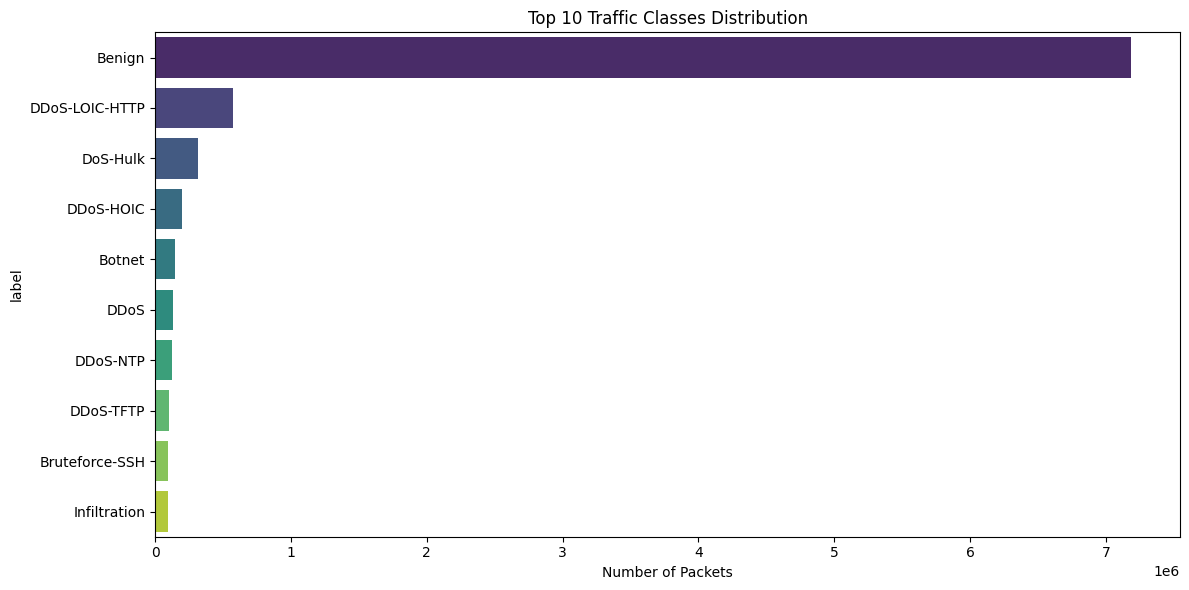


✅ label_mapping.json saved to ../data/processed
   Total Classes: 33
Dropped 'label' column. Using 'label_encoded' now.


In [4]:
# ==========================================
# 4. Label Analysis, Encoding & Mapping Save
# ==========================================
import json
import os

PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

target_col = 'label'

print(f"Analyzing Target Column: '{target_col}'")
print("=" * 40)

# A. Check Distribution
class_counts = df[target_col].value_counts()
class_percentage = df[target_col].value_counts(normalize=True) * 100

print("Class Distribution (Top 10):")
print(pd.concat([class_counts, class_percentage.round(2)], 
                axis=1, keys=['Count', 'Percentage']).head(10))

# B. Visualize
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.head(10).values, y=class_counts.head(10).index, palette='viridis')
plt.title('Top 10 Traffic Classes Distribution')
plt.xlabel('Number of Packets')
plt.tight_layout()
plt.show()

# C. Label Encoding
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df[target_col])

# D. IMMEDIATELY Save Label Mapping (CRITICAL FIX)
label_mapping = dict(zip(
    encoder.classes_.tolist(), 
    [int(x) for x in encoder.transform(encoder.classes_)]
))
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

label_map_path = os.path.join(PROCESSED_DIR, 'label_mapping.json')
with open(label_map_path, 'w') as f:
    json.dump({
        "label_to_int": label_mapping,
        "int_to_label": reverse_label_mapping
    }, f, indent=4)

print(f"\n✅ label_mapping.json saved to {PROCESSED_DIR}")
print(f"   Total Classes: {len(label_mapping)}")

# E. Drop original string label
df.drop(columns=[target_col], inplace=True)
print(f"Dropped '{target_col}' column. Using 'label_encoded' now.")

In [5]:
# ==========================================
# 5. Feature Engineering (MEMORY OPTIMIZED - 16GB RAM)
# ==========================================
import json
import gc
import os

PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# A. Remove Negative Values (inplace for memory)
neg_candidates = [col for col in df.columns if 
                  'header' in col or 'duration' in col or 
                  'iat' in col or 'length' in col]

rows_before = len(df)
mask = pd.Series(True, index=df.index)
for col in neg_candidates:
    if pd.api.types.is_numeric_dtype(df[col]):
        mask &= (df[col] >= 0)

df = df[mask]
del mask
gc.collect()
print(f"Dropped {rows_before - len(df):,} rows with negative values.")

# B. Fix init_win_bytes
win_cols = [col for col in df.columns if 'init' in col and 'win' in col]
for col in win_cols:
    df.loc[df[col] == -1, col] = 0

# C. Feature Engineering (memory safe)
print("Engineering rates...")
EPSILON = 1e-10

if 'flow_duration' in df.columns:
    duration = df['flow_duration'].values.clip(min=EPSILON)
    
    # Bytes rate
    if 'fwd_packets_length_total' in df.columns and 'bwd_packets_length_total' in df.columns:
        df['bytes_rate'] = ((df['fwd_packets_length_total'].values + 
                             df['bwd_packets_length_total'].values) / duration).astype(np.float32)
    
    # Packets rate  
    if 'total_fwd_packets' in df.columns and 'total_backward_packets' in df.columns:
        df['packets_rate'] = ((df['total_fwd_packets'].values + 
                               df['total_backward_packets'].values) / duration).astype(np.float32)
    
    del duration
    gc.collect()

# D. Clean infinities
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
gc.collect()

# E. Remove Zero Variance (simple check, no sklearn)
print("Removing zero-variance columns...")
cols_to_drop = []
for col in df.columns:
    if col != 'label_encoded' and df[col].nunique() <= 1:
        cols_to_drop.append(col)

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"   Dropped {len(cols_to_drop)} zero-variance columns")

gc.collect()

# F. SKIP CORRELATION CHECK (saves ~8GB RAM!)
# Instead, manually drop known redundant columns
print("Dropping known redundant columns (skip correlation matrix)...")
redundant_cols = [
    'subflow_fwd_packets', 'subflow_bwd_packets',  # duplicates of total_*
    'subflow_fwd_bytes', 'subflow_bwd_bytes',
    'fwd_packet_length_mean',  # correlated with avg_fwd_segment_size
]
actual_redundant = [c for c in redundant_cols if c in df.columns]
if actual_redundant:
    df.drop(columns=actual_redundant, inplace=True)
    print(f"   Dropped: {actual_redundant}")

gc.collect()

# G. Save Feature Map
final_features = [c for c in df.columns if c != 'label_encoded']

with open(os.path.join(PROCESSED_DIR, 'feature_map.json'), 'w') as f:
    json.dump({"features": final_features}, f, indent=4)

print("=" * 40)
print(f"✅ feature_map.json saved ({len(final_features)} features)")
print(f"Final Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

Dropped 53,880 rows with negative values.
Engineering rates...
Removing zero-variance columns...
Dropping known redundant columns (skip correlation matrix)...
   Dropped: ['subflow_fwd_packets', 'subflow_bwd_packets', 'subflow_fwd_bytes', 'subflow_bwd_bytes', 'fwd_packet_length_mean']
✅ feature_map.json saved (54 features)
Final Shape: (9113701, 55)
Memory: 2043 MB


In [6]:
# ==========================================
# 6. Stratified Split, Scaling & Final Saving
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import gc
import os
import json

PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# A. Separate Features & Target
X = df.drop(columns=['label_encoded'])
y = df['label_encoded']
feature_columns = X.columns.tolist()

print(f"Features: {len(feature_columns)}, Samples: {len(X):,}")

# B. Stratified Split
print("Splitting Data (80% Train / 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   Train: {X_train.shape}, Test: {X_test.shape}")

# Free memory
del df
gc.collect()

# C. Scaling (FIT ONLY ON TRAIN - NO DATA LEAKAGE)
print("\nFitting StandardScaler on TRAINING data only...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Transform only, no fit!

# D. Save Scaler
scaler_path = os.path.join(PROCESSED_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✅ scaler.pkl saved")

# E. Save Datasets as Parquet (float32 for memory efficiency)
print("\nSaving datasets to Parquet...")

pd.DataFrame(X_train_scaled, columns=feature_columns, dtype=np.float32).to_parquet(
    os.path.join(PROCESSED_DIR, 'X_train.parquet'), index=False
)
pd.DataFrame(X_test_scaled, columns=feature_columns, dtype=np.float32).to_parquet(
    os.path.join(PROCESSED_DIR, 'X_test.parquet'), index=False
)
pd.DataFrame({'label': y_train.values}).to_parquet(
    os.path.join(PROCESSED_DIR, 'y_train.parquet'), index=False
)
pd.DataFrame({'label': y_test.values}).to_parquet(
    os.path.join(PROCESSED_DIR, 'y_test.parquet'), index=False
)

print(f"✅ X_train.parquet: {X_train_scaled.shape}")
print(f"✅ X_test.parquet:  {X_test_scaled.shape}")
print(f"✅ y_train.parquet: ({len(y_train)},)")
print(f"✅ y_test.parquet:  ({len(y_test)},)")

# F. Final Verification
print("\n" + "=" * 50)
print("VERIFICATION")
print("=" * 50)

required_files = ['X_train.parquet', 'X_test.parquet', 'y_train.parquet', 
                  'y_test.parquet', 'scaler.pkl', 'feature_map.json', 'label_mapping.json']

all_ok = True
for f in required_files:
    path = os.path.join(PROCESSED_DIR, f)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f"✅ {f:<25} ({size_mb:.2f} MB)")
    else:
        print(f"❌ {f:<25} MISSING!")
        all_ok = False

print("\n" + "=" * 50)
print("🚀 STATUS: READY FOR TRAINING" if all_ok else "⛔ STATUS: FIX MISSING FILES")
print("=" * 50)

Features: 54, Samples: 9,113,701
Splitting Data (80% Train / 20% Test)...
   Train: (7290960, 54), Test: (1822741, 54)

Fitting StandardScaler on TRAINING data only...
✅ scaler.pkl saved

Saving datasets to Parquet...
✅ X_train.parquet: (7290960, 54)
✅ X_test.parquet:  (1822741, 54)
✅ y_train.parquet: (7290960,)
✅ y_test.parquet:  (1822741,)

VERIFICATION
✅ X_train.parquet           (790.72 MB)
✅ X_test.parquet            (199.12 MB)
✅ y_train.parquet           (2.87 MB)
✅ y_test.parquet            (0.71 MB)
✅ scaler.pkl                (0.00 MB)
✅ feature_map.json          (0.00 MB)
✅ label_mapping.json        (0.00 MB)

🚀 STATUS: READY FOR TRAINING


In [7]:
# ==========================================
# 7. Save Label Mapping (Production Artifact)
# ==========================================
import json
import os

PROCESSED_DIR = '../data/processed'

# Get mapping from the encoder (created in Cell 4)
label_mapping = dict(zip(encoder.classes_.tolist(), 
                         [int(x) for x in encoder.transform(encoder.classes_)]))
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

# Save both mappings
with open(os.path.join(PROCESSED_DIR, 'label_mapping.json'), 'w') as f:
    json.dump({
        "label_to_int": label_mapping,
        "int_to_label": reverse_label_mapping
    }, f, indent=4)

print(f"label_mapping.json saved ({len(label_mapping)} classes)")
print("\nSample mappings:")
for label, code in list(label_mapping.items())[:5]:
    print(f"   '{label}' -> {code}")

label_mapping.json saved (33 classes)

Sample mappings:
   'Benign' -> 0
   'Botnet' -> 1
   'Bruteforce-FTP' -> 2
   'Bruteforce-SSH' -> 3
   'DDoS' -> 4


In [8]:
# ==========================================
# 8. Final Verification
# ==========================================
import os

PROCESSED_DIR = '../data/processed'

print("=" * 50)
print("PRODUCTION ARTIFACTS VERIFICATION")
print("=" * 50)

expected_files = [
    'X_train.parquet', 'X_test.parquet', 
    'y_train.parquet', 'y_test.parquet',
    'scaler.pkl', 'feature_columns.pkl',
    'feature_map.json', 'label_mapping.json'
]

all_present = True
for fname in expected_files:
    fpath = os.path.join(PROCESSED_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        size_str = f"{size_kb/1024:.2f} MB" if size_kb > 1024 else f"{size_kb:.2f} KB"
        print(f"{fname:<25} ({size_str})")
    else:
        print(f"{fname:<25} MISSING!")
        all_present = False

print("\n" + "=" * 50)
if all_present:
    print("STATUS: GO FOR MODEL TRAINING")
else:
    print("STATUS: NO-GO")
print("=" * 50)

PRODUCTION ARTIFACTS VERIFICATION
X_train.parquet           (790.72 MB)
X_test.parquet            (199.12 MB)
y_train.parquet           (2.87 MB)
y_test.parquet            (730.68 KB)
scaler.pkl                (3.01 KB)
feature_columns.pkl       (0.64 KB)
feature_map.json          (1.43 KB)
label_mapping.json        (1.84 KB)

STATUS: GO FOR MODEL TRAINING
